# Cog 20 Tasks with a Dale RNN

Pedagogical notebook for the three-task battery in this repo, using the
**DaleRNN** in `network.py` (Dale's-law recurrent network based on LeakyRNN).

**Structure**
1. **Tasks & expected behavior** — what each trial looks like *before* learning
2. **DaleRNN** — excitatory/inhibitory recurrent network from `network.py`
3. **Training** — joint multitask learning on mixed batches
4. **Model performance** — does the trained network match the expected behavior?


## Shared trial format

All tasks use the same input/output channels and population coding on a ring $[0, 2\pi)$.

| Channel | Name | Role |
|---------|------|------|
| input 0 | fixation | 1 = hold fixation, 0 = go cue |
| input 1…`rule_start−1` | stimulus ring | Gaussian bump(s) at cue location(s) |
| input `rule_start`… | rule context | one-hot: **fdgo** / **delaygo** / **dm1** |
| output 0 | fixation | target $\approx 0.8$ before go |
| output 1… | response ring | bump at saccade target after go |

Stimulus and target locations are encoded as **Gaussian bumps** over `n_eachring` units with evenly spaced preferred angles (`Trial.add_x_loc` / `add_y_loc` in `task.py`).



| # | Task | Explanation |
|---|---|---|
| 1 | **`fdgo`**  | Stimulus shown, fixation drops, saccade to stimulus location. Nearly feedforward — no delay, no decision, no transformation. |
| 2 | **`reactgo`** | Same as `fdgo`, but there's no held fixation period before response — the network must respond immediately upon stimulus onset. Tests reaction-time-style immediate mapping rather than "wait for go cue" gating. |
| 3 | **`fdanti`** | Like `fdgo`, but the target is the *opposite* location on the ring, not the stimulus location. Requires learning a fixed spatial transformation (π rotation) — first task needing more than "copy the input." |
| 4 | **`delaygo`**  | Stimulus shown briefly, removed, then a delay before the go cue. Requires working memory to hold the location across a stimulus-free period — first task needing genuine recurrent maintenance. |
| 5 | **`delayanti`** | Combines 3 and 4: stimulus removed, held in memory during delay, then saccade to the *opposite* location. Tests memory + transformation together. |
| 6 | **`dm1`**  | Two simultaneous stimuli on one ring at different strengths; respond to the stronger one. First task requiring evidence accumulation/comparison, not just memory. |
| 7 | **`dm2`** | Identical computation to `dm1`, but stimuli are presented on the second ring/modality instead of the first. Mainly a generalization check — confirms the network learned "compare two stimuli," not "compare stimuli specifically on ring 1." |
| 8 | **`multidm`** | Two stimuli shown redundantly across *both* rings simultaneously; the network must combine evidence from both modalities to decide the stronger one. Harder than `dm1`/`dm2` because it requires integrating across separate input channels, not just within one. |
| 9 | **`contextdm1`** | Two stimuli shown on *both* rings, but a context/rule cue tells the network to base its decision only on ring 1 and ignore ring 2 entirely. First task requiring selective attention/gating — actively suppressing task-irrelevant input rather than combining or memorizing it. |
| 10 | **`dmsgo`** (delayed match-to-sample) | Two stimuli shown sequentially with a delay between them; respond one way if they're the same location, another way if different. Hardest of the set — requires memory *and* comparison *and* a categorical (same/different) decision built from continuous stimulus values, rather than a direct spatial or magnitude readout. |
| 11 | **`reactanti`** | Like `reactgo`, but the stimulus appears with no prior fixation-only cue and the network must respond immediately — combined with an anti-response (saccade to the *opposite* location, not the stimulus). Reactive timing + spatial inversion together, but no memory or integration needed. |
| 12 | **`dmsgo`-adjacent → `dmsnogo`** | Same delayed-match-to-sample structure as `dmsgo` (two sequential stimuli, judge same/different), but the correct response is to respond only if the stimuli *don't* match, otherwise stay at fixation (nogo). Tests response inhibition on top of memory + comparison. |
| 13 | **`delaydm1`** | Like `dm1`, but the two stimuli are shown sequentially (not simultaneously) with a delay between them — decide which was stronger after holding the first one in memory. Adds working memory on top of decision-making. |
| 14 | **`delaydm2`** | Identical computation to `delaydm1`, but stimuli are presented on ring 2 instead of ring 1 — generalization check for the delayed-decision computation. |
| 15 | **`contextdm2`** | Same as `contextdm1`, but the context cue now tells the network to attend to ring 2 and ignore ring 1. Confirms the network learned "selective attention," not "always attend to ring 1." |
| 16 | **`multidelaydm`** | Combines `multidm` (integrate evidence redundantly across both rings) with the sequential/delayed presentation from `delaydm1/2` — must hold and combine multi-modal evidence across a delay. |
| 17 | **`contextdelaydm1`** | `contextdm1`'s selective-attention decision, but with stimuli presented sequentially with a delay — selective attention *and* memory maintenance combined. |
| 18 | **`contextdelaydm2`** | Same as above, attending to ring 2 instead of ring 1 — generalization check for #17. |
| 19 | **`dmcgo`** | Delayed-match-to-*category*: two sequential stimuli, but instead of exact-location match, the network must judge whether they fall in the same half of the ring (category), then respond go/nogo accordingly. Requires learning a categorical boundary rather than a precise location comparison — a qualitatively different, more abstract computation than `dms`. |
| 20 | **`dmcnogo`** | Same categorical match judgment as `dmcgo`, with go/nogo contingency reversed (respond only on category mismatch). Hardest of the set — combines category abstraction, memory, comparison, and inhibitory control simultaneously. |

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch

from task import default_config, generate_trials, rules_dict, get_dist
from train_cog import (
    make_model,
    train_without_plots,
    plot_training,
    trial_to_tensors,
    evaluate_task,
    decode_ring,
    batch_accuracy,
    ring_prefs,
    circular_abs,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = default_config(n_eachring=16, seed=0, easy_task=True)
TASKS = tuple(rules_dict["all"])

print(f"device={device}")
print(f"n_input={config['n_input']}  n_output={config['n_output']}  rule_start={config['rule_start']}")
print(f"tasks={TASKS}")

device=cpu
n_input=20  n_output=17  rule_start=17
tasks=('fdgo', 'delaygo', 'dm1')


In [2]:
def ms(t_step, dt):
    return np.asarray(t_step, dtype=float) * dt


def decode_ring_np(ring, prefs):
    ring = np.atleast_2d(ring)
    cos_c = (ring * np.cos(prefs)).sum(axis=-1)
    sin_c = (ring * np.sin(prefs)).sum(axis=-1)
    return np.arctan2(sin_c, cos_c)


def _go_onset_step(trial):
    return trial.epochs.get("go1", (None, None))[0]


def plot_task_timeline(trial, title=None):
    dt = trial.dt
    colors = {"fix1": "#999999", "stim1": "C0", "delay1": "C1", "go1": "C3"}
    fig, ax = plt.subplots(figsize=(10, 3))
    for name, (start, end) in trial.epochs.items():
        s = 0 if start is None else start
        e = trial.tdim if end is None else end
        ax.barh(0.5, (e - s) * dt, left=s * dt, height=0.55,
                color=colors.get(name, "gray"), label=name, edgecolor="white")
    ax.set_xlim(0, trial.tdim * dt)
    ax.set_xticks([])
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("time (ms)")
    ax.set_title(title or "Trial phases")
    ax.legend(loc="upper right", ncol=4, fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig


def plot_trial_ideal(trial, config, i=0, title=None):
    """Expected inputs and targets (teacher signal)."""
    dt = config["dt"]
    rule_start = config["rule_start"]
    prefs = trial.pref
    T = trial.tdim
    t_ms = ms(np.arange(T), dt)
    x = trial.x[:, i]
    y = trial.y[:, i]
    go_ms = _go_onset_step(trial) * dt

    fig = plt.figure(figsize=(11, 10), layout="constrained")
    gs = GridSpec(3, 1, height_ratios=[1, 1.35, 1.35])
    ax0, ax1, ax2 = [fig.add_subplot(gs[r]) for r in range(3)]

    ax0.plot(t_ms, x[:, 0], "k-", lw=1.5, label="fixation in")
    ax0.plot(t_ms, 1.0 - x[:, 0], color="C3", lw=1.5, label="go cue (1-fix)")
    ax0.plot(t_ms, x[:, rule_start:].max(axis=1), color="C1", lw=1.2, label="rule context")
    ax0.set_ylabel("scalar inputs")
    ax0.set_ylim(-0.05, 1.15)
    ax0.legend(loc="upper right", fontsize=8)
    ax0.grid(True, alpha=0.3)

    stim_ring = x[:, 1:rule_start].T
    im1 = ax1.imshow(stim_ring, aspect="auto", origin="lower", cmap="Blues",
                     extent=[0, t_ms[-1] + dt, 0, len(prefs) - 1], vmin=0)
    ax1.set_ylabel("ring unit")
    ax1.set_title("Input stimulus ring")
    ax1b = ax1.twinx()
    ax1b.plot(t_ms, np.degrees(decode_ring_np(x[:, 1:rule_start], prefs)), "r-", lw=0.9, alpha=0.75)
    ax1b.set_ylabel("decoded input (deg)", color="r")
    ax1b.set_yticks([])
    fig.colorbar(im1, ax=ax1, fraction=0.025, pad=0.02, label="input amp")

    ax2.plot(t_ms, y[:, 0], "k--", lw=1.2, label="fixation target")
    im2 = ax2.imshow(y[:, 1:].T, aspect="auto", origin="lower", cmap="Oranges",
                     extent=[0, t_ms[-1] + dt, 0, len(prefs) - 1], vmin=0)
    ax2.set_ylabel("ring unit")
    ax2.set_xlabel("time (ms)")
    ax2.set_title("Target output (fixation + response ring)")
    ax2.legend(loc="upper left", fontsize=8)
    fig.colorbar(im2, ax=ax2, fraction=0.025, pad=0.02, label="target amp")

    for ax in (ax0, ax1, ax2):
        ax.axvline(go_ms, color="gray", ls="--", alpha=0.75, lw=1)
    if title:
        fig.suptitle(title, fontsize=13)
    plt.show()
    return fig


def plot_dm1_stim_snapshot(trial, config, i=0):
    """1D plot of the two simultaneous input bumps during stim1 (dm1 only)."""
    rule_start = config["rule_start"]
    prefs = trial.pref
    stim_on = trial.epochs["stim1"][0]
    ring = trial.x[stim_on, i, 1:rule_start]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(prefs, ring, "C0", lw=2)
    ax.set_title(f"dm1 input ring at stim onset (t={stim_on * config['dt']:.0f} ms)")
    ax.set_xlabel("angle (rad)")
    ax.set_ylabel("amplitude")
    ax.grid(True, alpha=0.3)
    plt.show()
    return fig





def demo_expected(task, title=None):
    trial = generate_trials(task, config, batch_size=1, noise_on=False)
    plot_task_timeline(trial, title=f"{task} — trial timeline")
    plot_trial_ideal(trial, config, title=title or f"{task} — expected behavior")
    if task == "dm1":
        plot_dm1_stim_snapshot(trial, config)
    return trial


def plot_model_vs_expected(model, config, task, device):
    """Side-by-side: teacher targets vs trained network output on one trial."""
    trial = generate_trials(task, config, batch_size=1, noise_on=False)
    x, y, _, y_loc = trial_to_tensors(trial, device)
    with torch.no_grad():
        _, _, output = model.simulate(x, noise_level=0.0)

    dt = config["dt"]
    t_ms = ms(np.arange(trial.tdim), dt)
    y_np = y[0].cpu().numpy()
    out_np = output[0].cpu().numpy()
    go_ms = _go_onset_step(trial) * dt
    prefs_t = ring_prefs(config, device, output.dtype)
    pred_ang = decode_ring(output, prefs_t)[0].cpu().numpy()
    tgt_ang = decode_ring_np(y_np[:, 1:], trial.pref)
    acc = batch_accuracy(output, y_loc, prefs_t)

    fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True, layout="constrained",
                             height_ratios=[0.9, 1.4, 1.4, 0.9])

    axes[0].plot(t_ms, y_np[:, 0], "k--", lw=1.2, label="target fix")
    axes[0].plot(t_ms, out_np[:, 0], "C3", lw=1.5, label="model fix")
    axes[0].set_ylabel("fixation")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    vmax = max(y_np[:, 1:].max(), out_np[:, 1:].max(), 0.1)
    axes[1].imshow(y_np[:, 1:].T, aspect="auto", origin="lower", cmap="Oranges",
                   extent=[0, t_ms[-1] + dt, 0, config["n_eachring"] - 1], vmin=0, vmax=vmax)
    axes[1].set_ylabel("ring unit")
    axes[1].set_title("Expected response ring")

    axes[2].imshow(out_np[:, 1:].T, aspect="auto", origin="lower", cmap="Greens",
                   extent=[0, t_ms[-1] + dt, 0, config["n_eachring"] - 1], vmin=0, vmax=vmax)
    axes[2].set_ylabel("ring unit")
    axes[2].set_title("Model response ring")

    axes[3].plot(t_ms, np.degrees(tgt_ang), "k--", lw=1.5, label="target angle")
    axes[3].plot(t_ms, np.degrees(pred_ang), "C2", lw=1.5, label="model angle")
    axes[3].set_xlabel("time (ms)")
    axes[3].set_ylabel("angle (deg)")
    axes[3].legend(fontsize=8)
    axes[3].grid(True, alpha=0.3)

    for ax in axes:
        ax.axvline(go_ms, color="gray", ls="--", alpha=0.7)
    fig.suptitle(f"{task} — expected vs model (acc={acc['acc']:.2f})", fontsize=13)
    plt.show()
    return acc


---
## Part 1 — Tasks and expected behavior

Below we visualize the **teacher signal** the network is trained to reproduce.
No learning has happened yet — these plots define what "correct" means.

### `fdgo` — fixation-duration go

**Rule:** Stimulus stays on until the go cue. After fixation offset, saccade to the **visible** stimulus location.

**Cognitive demand:** Minimal working memory — the input ring carries the target location throughout the pre-go period.

**Expected behavior**
- **Pre-go:** hold fixation (output channel 0 high); response ring flat
- **Post-go:** fixation drops; response ring bump at the stimulus angle

**Phases:** `fix1` → `stim1` (overlapping) → `go1`

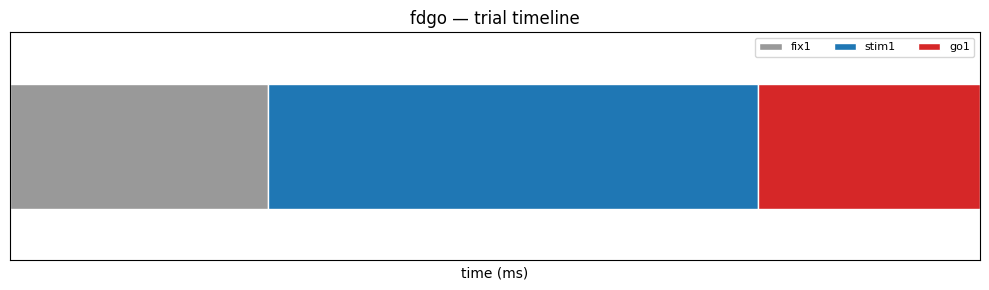

c:\Users\athar\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


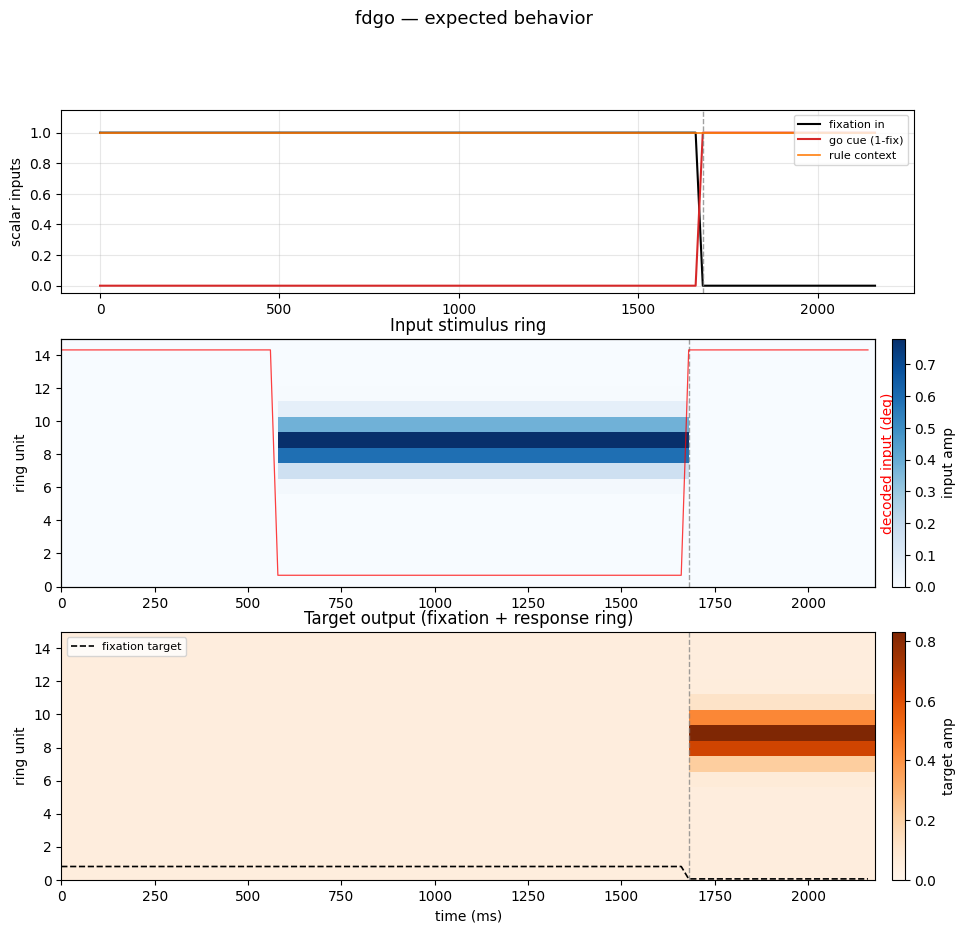

In [3]:
trial_fdgo = demo_expected('fdgo', title='fdgo — expected behavior')

### `delaygo` — working-memory go

**Rule:** Stimulus is shown briefly, then **removed** during a delay. At go, saccade to the **remembered** location.

**Cognitive demand:** The network must maintain the cue location internally during `delay1` when the input ring is blank.

**Expected behavior**
- **During `stim1`:** input ring shows the cue bump
- **During `delay1`:** no stimulus on input, but the target angle must be remembered
- **After go:** response ring bump at the memorized angle

**Phases:** `fix1` → `stim1` → `delay1` → `go1`

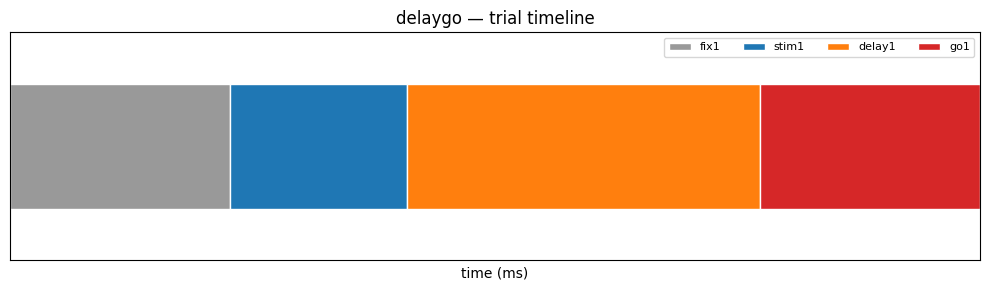

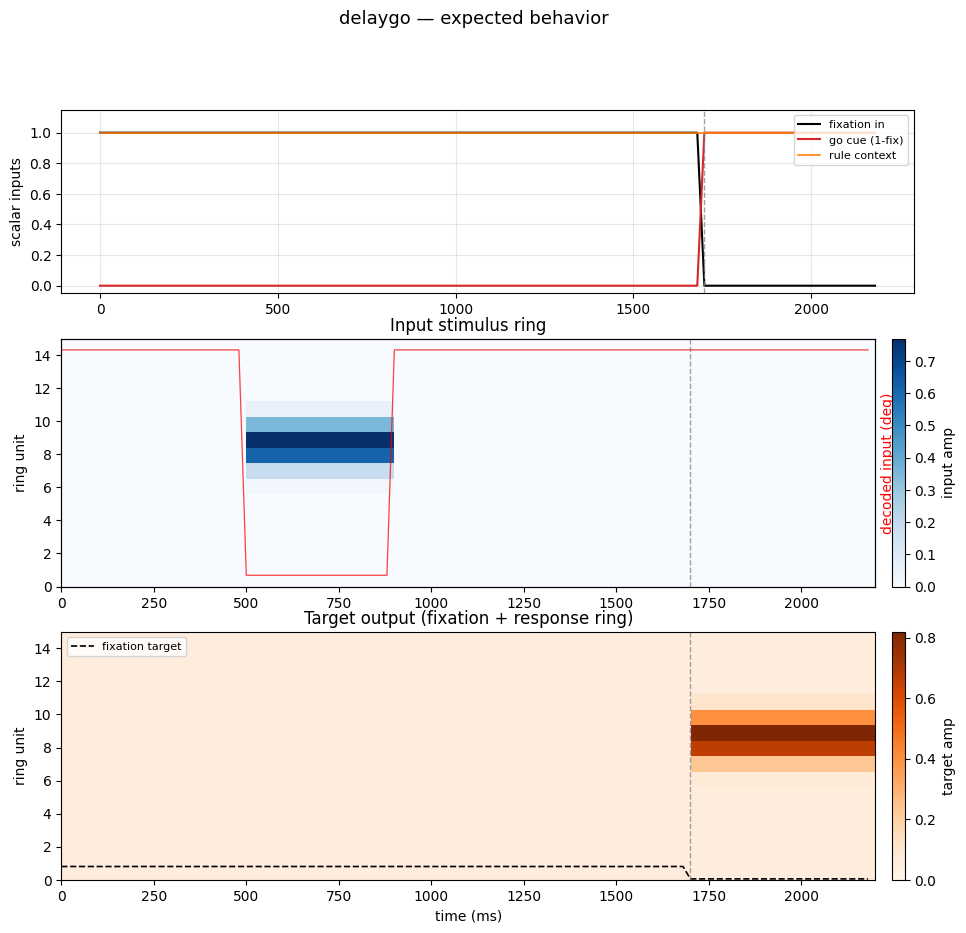

In [4]:
trial_delaygo = demo_expected('delaygo', title='delaygo — expected behavior')

### `dm1` — perceptual decision (two stimuli)

**Rule:** Two stimuli appear **simultaneously** on the same ring with different strengths (coherence). Integrate evidence during `stim1`, then at go saccade to the **stronger** stimulus location.

**Cognitive demand:** Compare two overlapping Gaussian bumps and choose the winner — a classic random-dot–style decision on a ring.

**Expected behavior**
- **During `stim1`:** input ring shows **two bumps** at different angles with unequal amplitudes
- **Pre-go:** hold fixation; response ring flat
- **After go:** response ring shows a **single** bump at the stronger stimulus angle

**Phases:** `fix1` → `stim1` → `go1`


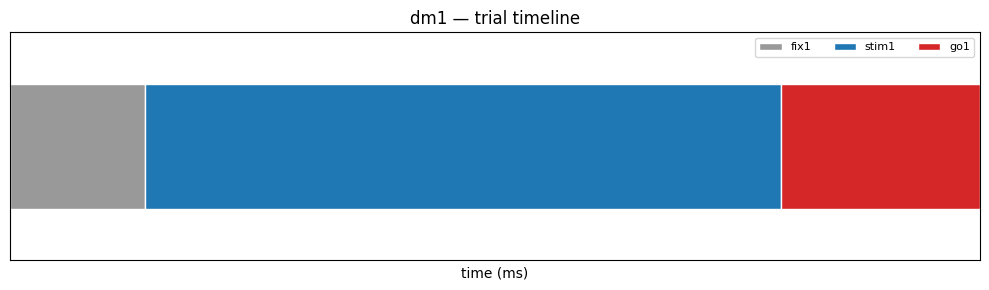

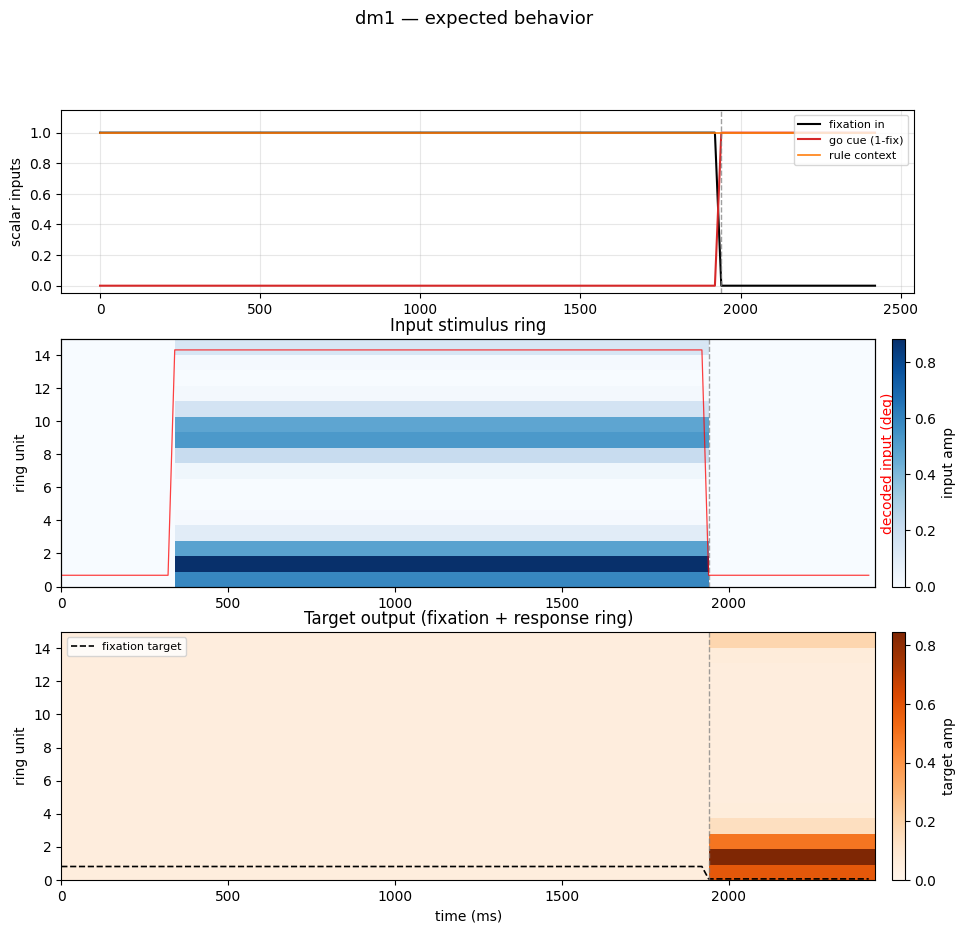

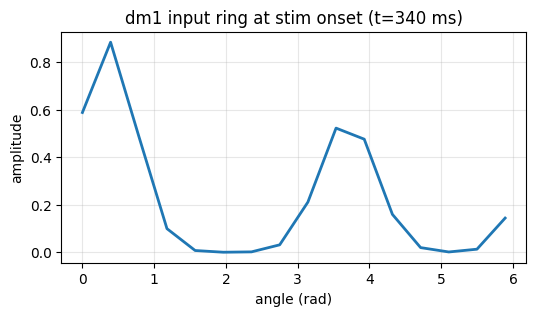

In [5]:
trial_dm1 = demo_expected('dm1', title='dm1 — expected behavior')


---
## Part 2 — DaleRNN

We train **DaleRNN** from `network.py` — a Dale's-law variant of the leaky RNN:

- Hidden state: $h_t = (1-\alpha) h_{t-1} + \alpha f(W_{\mathrm{rec}} h_{t-1} + W_{\mathrm{in}} x_t + b)$ with $\alpha = dt/\tau$
- **Recurrent weights:** $W_{\mathrm{rec}} = \mathrm{softplus}(W_{\mathrm{raw}}) \odot \mathrm{sign}$ with fixed presynaptic E/I signs; no autapses
- **ReLU** activation (nonnegative firing rates); **sigmoid** readout from **excitatory units only**
- E/I split: `frac_e` excitatory (default 80%), near-critical init with $\rho(W_{\mathrm{rec}}) \approx g$
- No recurrent noise during training (unlike Yang LeakyRNN)
- Loss: mask-weighted MSE (`c_mask` in `task.py`) on fixation + response ring


In [6]:
N_NEURONS = 128
FRAC_E = 0.8
TARGET_RHO = 1.0

model = make_model(
    config,
    model_type="dale",
    n_neurons=N_NEURONS,
    frac_e=FRAC_E,
    g=TARGET_RHO,
    activation="relu",
    w_rec_init="randortho",
    seed=0,
    device=str(device),
)
print(
    f"DaleRNN on {device}, N={N_NEURONS}, n_e={model.n_e}, n_i={model.n_i}, "
    f"alpha={config['alpha']:.3f}, rho(W)={model.recurrent_spectral_radius():.3f}"
)


DaleRNN: N=128  frac_e=0.8  rho(W)=1.000  activation=relu
DaleRNN on cpu, N=128, n_e=102, n_i=26, alpha=0.200, rho(W)=1.000


---
## Part 3 — Joint training

Each training step uses a **mixed batch**: roughly equal trials from `fdgo`, `delaygo`, and `dm1`, padded to a common length.

`delaygo` and `dm1` typically need more steps than `fdgo` (memory and evidence integration). Increase `N_STEPS` if accuracy is still low.


step    1 | train 0.2624 (mixed) | fdgo accuracy:0.000 go:0.28 fix:0.11 loss:0.3015 | delaygo accuracy:0.031 go:0.03 fix:1.00 loss:0.2753 | dm1 accuracy:0.016 go:0.33 fix:0.17 loss:0.2963 | sat:0.00; silent:0.56
step  100 | train 0.0831 (mixed) | fdgo accuracy:0.281 go:0.28 fix:1.00 loss:0.0537 | delaygo accuracy:0.156 go:0.16 fix:1.00 loss:0.0904 | dm1 accuracy:0.188 go:0.19 fix:1.00 loss:0.0560 | sat:0.00; silent:0.11
step  200 | train 0.0473 (mixed) | fdgo accuracy:0.328 go:0.33 fix:1.00 loss:0.0525 | delaygo accuracy:0.219 go:0.22 fix:1.00 loss:0.0419 | dm1 accuracy:0.281 go:0.28 fix:1.00 loss:0.1005 | sat:0.00; silent:0.11
step  300 | train 0.0480 (mixed) | fdgo accuracy:0.344 go:0.34 fix:1.00 loss:0.0569 | delaygo accuracy:0.125 go:0.12 fix:1.00 loss:0.0539 | dm1 accuracy:0.391 go:0.39 fix:1.00 loss:0.0643 | sat:0.00; silent:0.10
step  400 | train 0.0434 (mixed) | fdgo accuracy:0.453 go:0.45 fix:1.00 loss:0.0493 | delaygo accuracy:0.250 go:0.25 fix:1.00 loss:0.0664 | dm1 accuracy

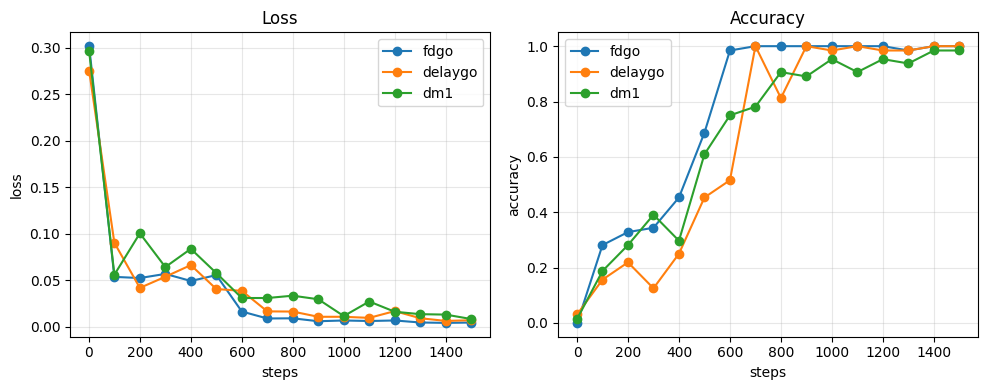

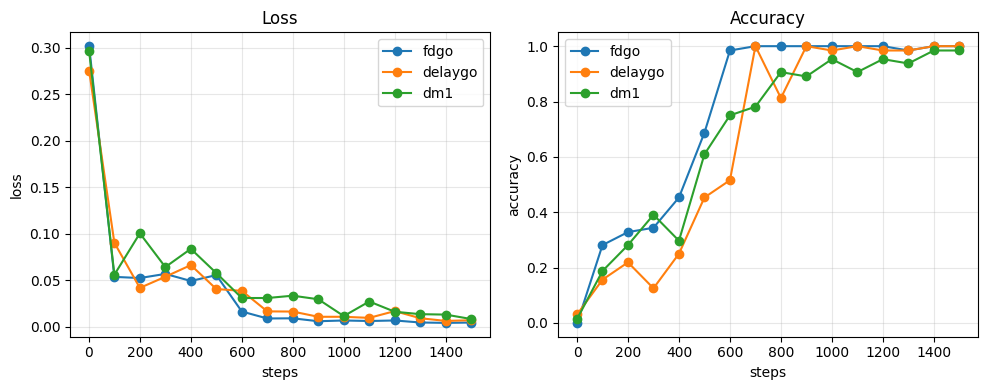

In [7]:
N_STEPS = 1500
BATCH_SIZE = 64
LR = 1e-3

history = train_without_plots(
    model,
    config,
    active_tasks=TASKS,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    log_every=100,
    noise_level=0.0,
    lambda_rate=0.0,
)
plot_training(history, TASKS)


---
## Part 4 — Does the model perform as expected?

We evaluate on fresh trials and compare network outputs to the teacher targets from Part 1.

**Accuracy** (`batch_accuracy` in `train_cog.py`): a trial counts as correct when
1. mean predicted fixation $> 0.5$ during the fixation epoch, and
2. population-vector decode error $< \pi/5$ rad ($\approx 36°$) after go.

In [8]:
print(f"{'task':8s}  {'acc':>5s}  {'go':>5s}  {'fix':>5s}  {'loss':>8s}")
print("-" * 40)
for task in TASKS:
    m = evaluate_task(model, config, task, batch_size=64, device=str(device))
    print(
        f"{task:8s}  {m['acc']:5.3f}  {m['go_acc']:5.2f}  {m['fix_acc']:5.2f}  {m['loss']:8.4f}"
    )

task        acc     go    fix      loss
----------------------------------------
fdgo      1.000   1.00   1.00    0.0045
delaygo   1.000   1.00   1.00    0.0079
dm1       0.938   0.94   1.00    0.0087


### `fdgo` — trained network

For **fdgo**, the model should hold fixation pre-go and shift a response bump to the stimulus angle after the go cue — matching the expected trial above.

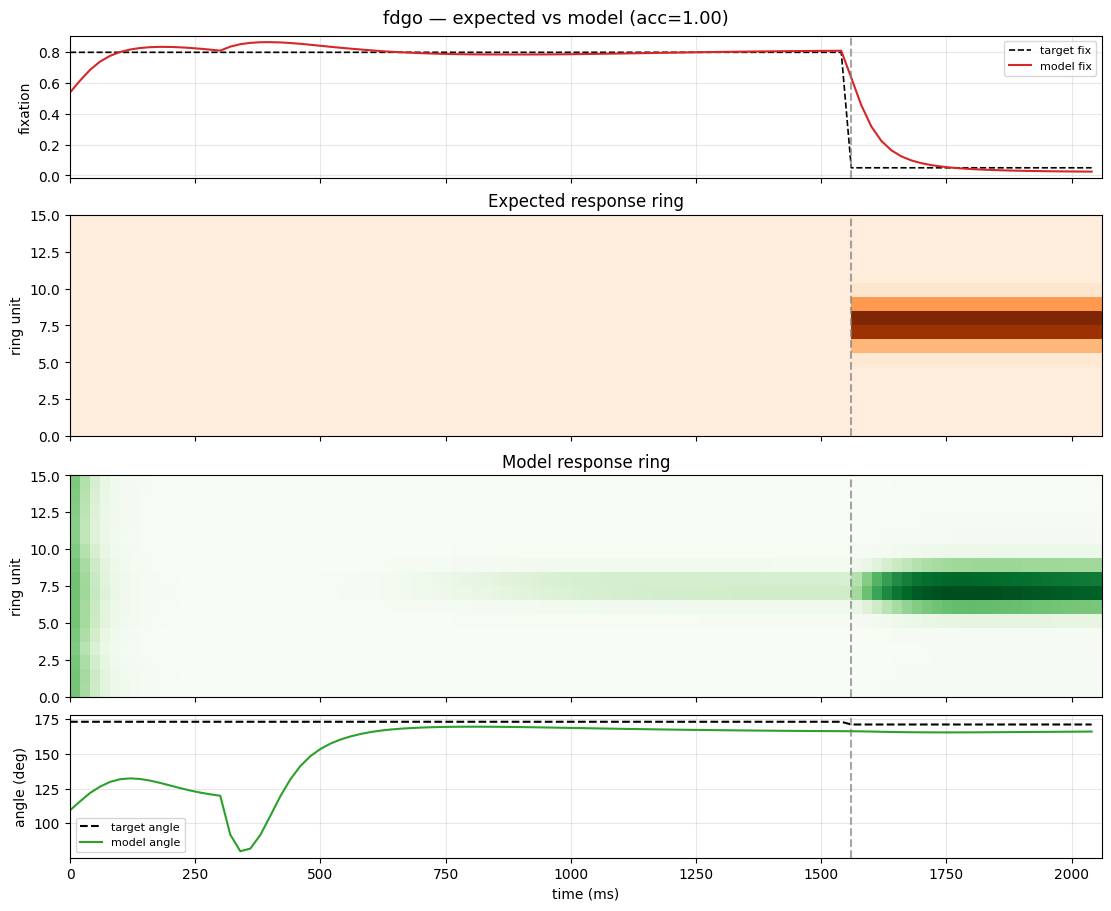

{'acc': 1.0, 'go_acc': 1.0, 'fix_acc': 1.0}

In [9]:
plot_model_vs_expected(model, config, 'fdgo', device)

### `delaygo` — trained network

For **delaygo**, the critical check is **memory across the blank delay**: decoded output angle should track the target even when the input ring is off, then produce the saccade bump at go.

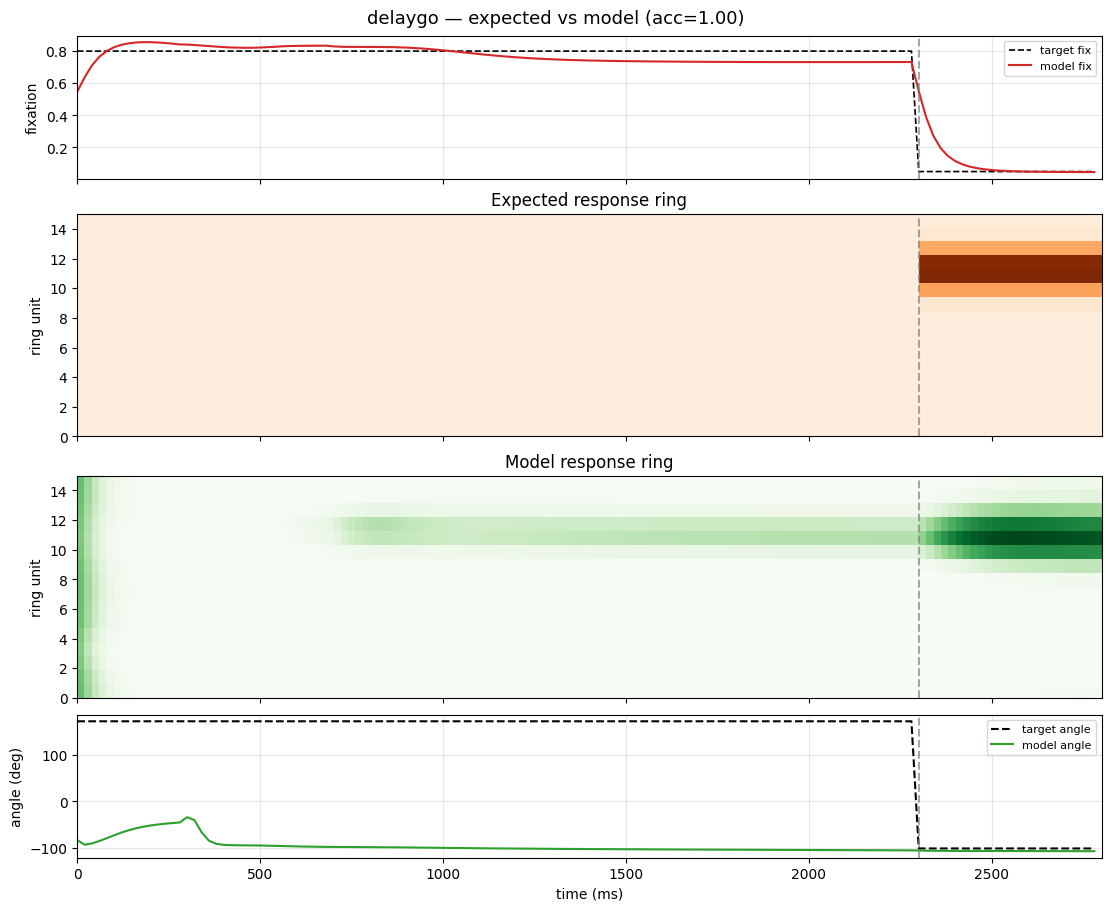

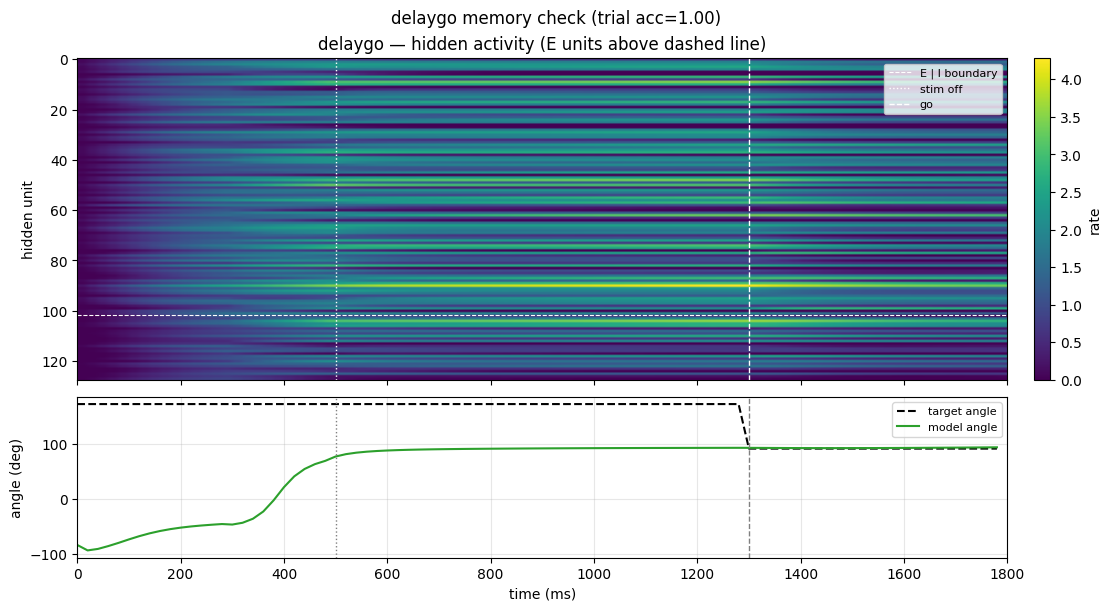

In [10]:
acc_delaygo = plot_model_vs_expected(model, config, 'delaygo', device)

# Hidden-state view: does activity persist through delay1?
task = "delaygo"
trial = generate_trials(task, config, batch_size=1, noise_on=False)
x, y, _, y_loc = trial_to_tensors(trial, device)
with torch.no_grad():
    r_hist, _, output = model.simulate(x, noise_level=0.0)

dt = config["dt"]
t_ms = ms(np.arange(trial.tdim), dt)
r_np = r_hist[0].cpu().numpy().T
prefs_t = ring_prefs(config, device, output.dtype)
pred_ang = decode_ring(output, prefs_t)[0].cpu().numpy()
tgt_ang = decode_ring_np(y[0].cpu().numpy()[:, 1:], trial.pref)
stim_off = trial.epochs["stim1"][1] * dt
go_ms = _go_onset_step(trial) * dt

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained", height_ratios=[2, 1])
im = axes[0].imshow(r_np, aspect="auto", origin="upper", cmap="viridis",
                    extent=[0, t_ms[-1] + dt, r_np.shape[0] - 0.5, -0.5])
axes[0].axhline(model.n_e - 0.5, color="w", ls="--", lw=0.8, label="E | I boundary")
axes[0].axvline(stim_off, color="w", ls=":", lw=1, label="stim off")
axes[0].axvline(go_ms, color="w", ls="--", lw=1, label="go")
axes[0].set_ylabel("hidden unit")
axes[0].set_title("delaygo — hidden activity (E units above dashed line)")
axes[0].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[0], fraction=0.02, pad=0.01, label="rate")

axes[1].plot(t_ms, np.degrees(tgt_ang), "k--", lw=1.5, label="target angle")
axes[1].plot(t_ms, np.degrees(pred_ang), "C2", lw=1.5, label="model angle")
axes[1].axvline(stim_off, color="gray", ls=":", lw=1)
axes[1].axvline(go_ms, color="gray", ls="--", lw=1)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("angle (deg)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
fig.suptitle(f"delaygo memory check (trial acc={acc_delaygo['acc']:.2f})")
plt.show()


### `dm1` — trained network

For **dm1**, the model should integrate the two input bumps during `stim1` and produce a single response bump at the **stronger** stimulus after go.


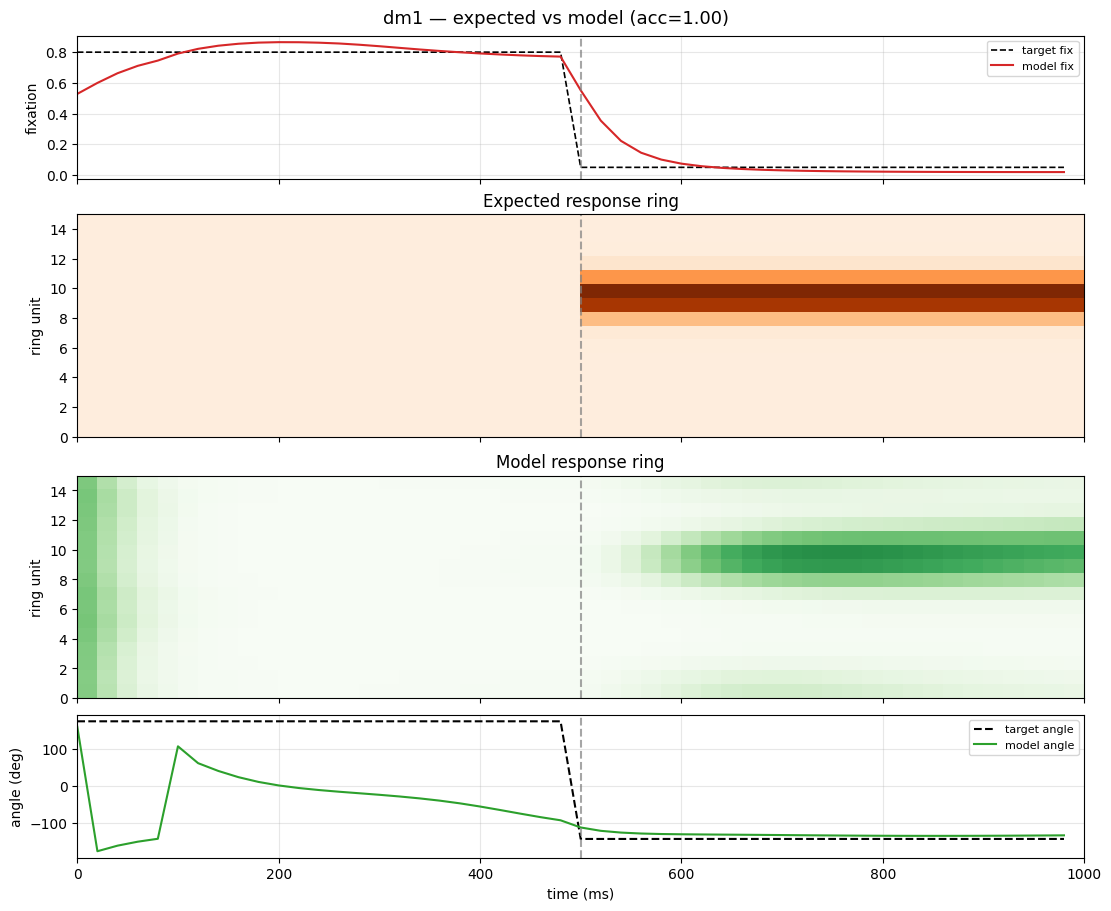

{'acc': 1.0, 'go_acc': 1.0, 'fix_acc': 1.0}

In [11]:
plot_model_vs_expected(model, config, 'dm1', device)


### Batch decode-error distribution

Histogram of angular errors during the go epoch across a batch of trials. Most mass should fall below 36° if the network meets the performance criterion.

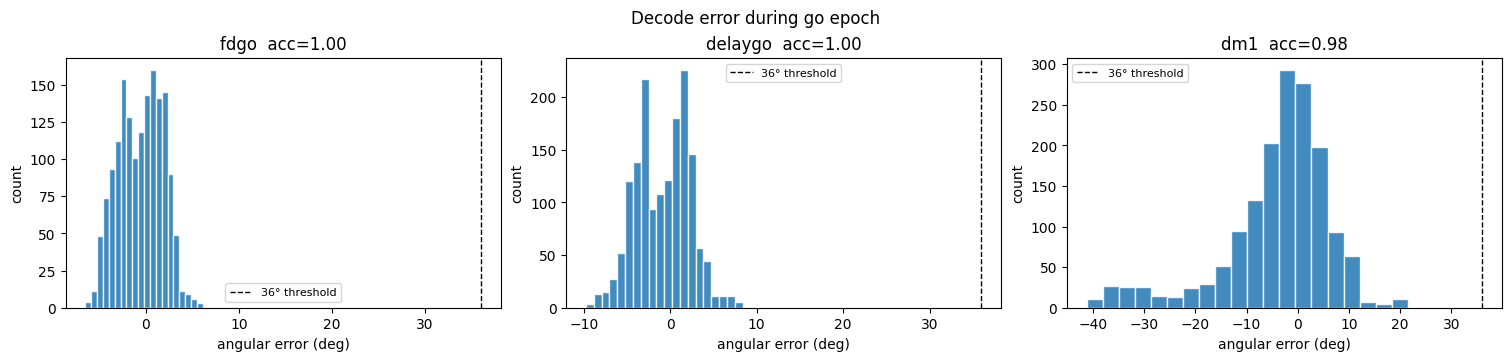

In [12]:
prefs = ring_prefs(config, device, torch.float32)
fig, axes = plt.subplots(1, len(TASKS), figsize=(5 * len(TASKS), 3.5), layout="constrained", squeeze=False)

for ax, task in zip(axes[0], TASKS):
    trial = generate_trials(task, config, batch_size=64, noise_on=True)
    x, _, _, y_loc = trial_to_tensors(trial, device)
    with torch.no_grad():
        _, _, output = model.simulate(x, noise_level=0.0)
    pred_loc = decode_ring(output, prefs)
    go = y_loc >= 0
    err_deg = (circular_abs((pred_loc - y_loc).masked_fill(~go, 0.0))[go].cpu().numpy().ravel()
               * 180 / math.pi)
    acc = batch_accuracy(output, y_loc, prefs)
    ax.hist(err_deg, bins=20, color="C0", alpha=0.85, edgecolor="white")
    ax.axvline(36, color="k", ls="--", lw=1, label="36° threshold")
    ax.set_title(f"{task}  acc={acc['acc']:.2f}")
    ax.set_xlabel("angular error (deg)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

fig.suptitle("Decode error during go epoch")
plt.show()